# Karachi AQI — Exploratory Data Analysis

## 1. Load and Inspect the Dataset

In this notebook, we will perform Exploratory Data Analysis (EDA) on the Karachi AQI dataset stored in Hopsworks.

The purpose of EDA is to understand the structure, quality, patterns, relationships, and unusual behavior in the data before making further feature-engineering or modeling decisions.

### What we want to understand

- How much data do we have?
- Is the data complete?
- Is the data recorded at regular time intervals?
- How does AQI behave over time?
- Are there seasonal, daily, or hourly patterns?
- Which environmental variables are strongly related to AQI?
- Are there unusual values or outliers?
- What patterns can help us improve our forecasting models?

We will use these findings to make evidence-based decisions about feature engineering and model development.

In [ ]:
import os
import hopsworks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
project = hopsworks.login(api_key_value=os.getenv("HOPSWORKS_API_KEY"))
fs=project.get_feature_store()

fg= fs.get_feature_group(name="karachi_aqi_features", version=6)
df=fg.read()
df=df.sort_values("timestamp").reset_index(drop=True)

df["datetime"]=pd.to_datetime(df["timestamp"], unit="ms")

print("Shape: ", df.shape)
print(df[["datetime", "target_aqi"]].head())

2026-08-21 21:48:57,813 INFO: Closing external client and cleaning up certificates.
2026-08-21 21:48:57,816 INFO: Connection closed.
2026-08-21 21:48:57,819 INFO: Initializing external client
2026-08-21 21:48:57,821 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-21 21:49:00,103 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41100
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.82s) 
Shape:  (17544, 18)
             datetime  target_aqi
0 2024-08-01 00:00:00   65.613213
1 2024-08-01 01:00:00   65.597488
2 2024-08-01 02:00:00   65.605347
3 2024-08-01 03:00:00   65.715408
4 2024-08-01 04:00:00   65.896225


## 2. Understanding the Dataset Structure

Before analyzing patterns, we first inspect the columns, data types, and number of observations.

This helps us understand:
- Which columns are numerical features.
- Which column represents time.
- Which column is our prediction target.
- Whether any columns have an unexpected data type.
- The overall structure of the dataset.

In [26]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Information:")
df.info()

Number of rows: 17544
Number of columns: 18

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   city              17544 non-null  object        
 1   timestamp         17544 non-null  int64         
 2   pm25              17544 non-null  float64       
 3   pm10              17544 non-null  float64       
 4   ozone             17544 non-null  float64       
 5   nitrogen_dioxide  17544 non-null  float64       
 6   sulphur_dioxide   17544 non-null  float64       
 7   carbon_monoxide   17544 non-null  float64       
 8   temperature       17544 non-null  float64       
 9   humidity          17544 non-null  float64       
 10  humidex           17544 non-null  float64       
 11  aqi_change_rate   17544 non-null  float64       
 12  hour              17544 non-null  int64         
 13  day        

## 2. Target AQI Distribution

Before building or modifying predictive features, we examine the distribution of the target variable (`target_aqi`).

This helps us understand:
- the typical AQI range,
- whether the target is normally distributed,
- whether there are unusually high AQI values,
- and whether a transformation or special treatment may be needed later.

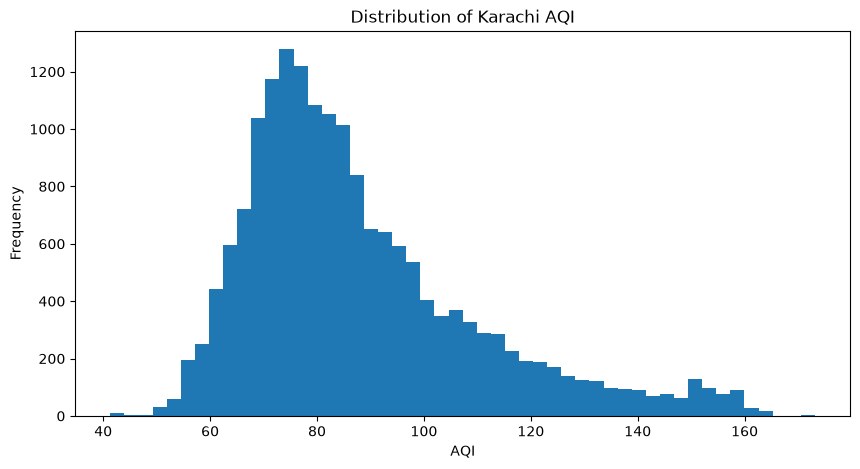

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["target_aqi"], bins=50)

plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.title("Distribution of Karachi AQI")

plt.show()

In [28]:
print("AQI Distribution Statistics")
print("-" * 40)

print(f"Mean   : {df['target_aqi'].mean():.2f}")
print(f"Median : {df['target_aqi'].median():.2f}")
print(f"Std    : {df['target_aqi'].std():.2f}")
print(f"Min    : {df['target_aqi'].min():.2f}")
print(f"Max    : {df['target_aqi'].max():.2f}")
print(f"Skewness: {df['target_aqi'].skew():.3f}")

print("\nAQI Percentiles")
print("-" * 40)
print(df['target_aqi'].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))

AQI Distribution Statistics
----------------------------------------
Mean   : 88.02
Median : 82.46
Std    : 21.96
Min    : 41.34
Max    : 173.15
Skewness: 1.174

AQI Percentiles
----------------------------------------
0.01     55.435770
0.05     61.996854
0.25     72.735853
0.50     82.460693
0.75     97.956785
0.95    134.995312
0.99    156.093238
Name: target_aqi, dtype: float64


### AQI Distribution — Numerical Analysis

The AQI distribution shows a positive (right) skew. The mean AQI (88.02) is higher than the median (82.46), and the skewness is 1.174, confirming that the distribution is noticeably right-skewed.

The 95th and 99th percentiles are 134.99 and 156.09 respectively, while the maximum AQI is 173.15. This indicates the presence of higher-AQI observations forming a right tail.

However, high AQI values are not automatically treated as outliers because they may represent genuine pollution events. Therefore, before removing or transforming these observations, we will examine whether high AQI values are supported by corresponding pollutant concentrations.

### Investigating High-AQI Observations

The AQI distribution has a long right tail, with the 95th percentile at approximately 135 and the maximum at 173. Before treating these high values as outliers, we need to determine whether they are supported by corresponding pollutant concentrations.

We will examine the pollutant statistics for the highest 5% of AQI observations.

In [29]:
high_aqi = df[df["target_aqi"] >= df["target_aqi"].quantile(0.95)]

print("High-AQI observations (top 5%):", len(high_aqi))

print("\nHigh-AQI statistics:")
print(
    high_aqi[
        [
            "target_aqi",
            "pm25",
            "pm10",
            "ozone",
            "nitrogen_dioxide",
            "sulphur_dioxide",
            "carbon_monoxide",
            "temperature",
            "humidity"
        ]
    ].describe().round(2)
)

High-AQI observations (top 5%): 878

High-AQI statistics:
       target_aqi    pm25    pm10   ozone  nitrogen_dioxide  sulphur_dioxide  \
count      878.00  878.00  878.00  878.00            878.00           878.00   
mean       148.36   51.76   67.61   84.73             34.34            24.23   
std          7.91   16.63   30.30   50.89             26.00            10.21   
min        135.00   12.30   16.10    2.00              3.10             5.90   
25%        141.12   39.60   49.00   40.25             12.92            17.10   
50%        149.47   50.45   63.10   83.00             26.70            22.10   
75%        154.50   63.60   77.80  129.00             49.80            29.18   
max        173.15  108.70  290.60  197.00            125.90            61.50   

       carbon_monoxide  temperature  humidity  
count           878.00       878.00    878.00  
mean            983.05        22.33     50.28  
std             503.90         4.82     17.54  
min             139.00       

### High-AQI Investigation — Findings

The top 5% of AQI observations contain 878 records with a mean AQI of 148.36 and a maximum of 173.15. These high-AQI observations are accompanied by elevated pollutant concentrations, particularly PM2.5, PM10, ozone, nitrogen dioxide, sulphur dioxide, and carbon monoxide.

This suggests that the high AQI values are likely to represent genuine high-pollution conditions rather than erroneous observations. Therefore, we will retain these observations and avoid removing them solely based on statistical outlier detection.

This finding is important for model development because extreme pollution events are meaningful for AQI forecasting and should be learned by the model.

### AQI Time-Series Analysis

Since this project focuses on forecasting future AQI values, it is important to understand how AQI changes over time. A time-series plot can reveal long-term trends, seasonal behavior, recurring patterns, and sudden pollution spikes that may influence forecasting performance.

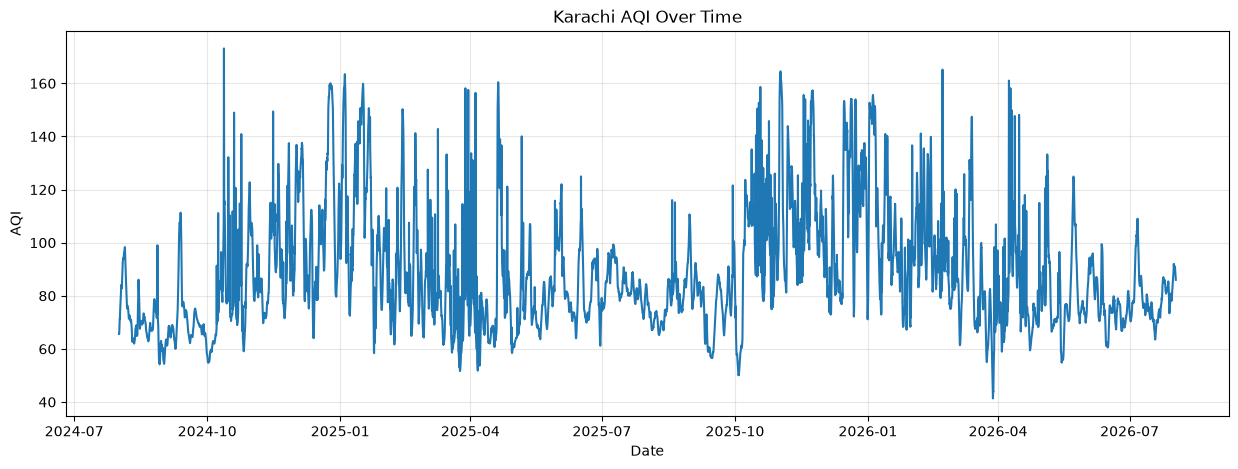

In [30]:
plt.figure(figsize=(15, 5))

plt.plot(df["datetime"], df["target_aqi"])

plt.title("Karachi AQI Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")

plt.grid(True, alpha=0.3)
plt.show()

### Time-Series Findings

The AQI time series shows strong temporal dependence with continuous hourly fluctuations and several pronounced pollution spikes. The data also suggests seasonal behavior, with generally higher AQI levels during some winter months.

Because the dataset contains hourly observations, the full time-series plot is visually dense. Therefore, aggregation will be used for visualization purposes only, while the original hourly data will be preserved for model training.

The observed temporal and seasonal patterns support the use of lag-based and time-based features for AQI forecasting.

### Monthly AQI Analysis

The time-series plot suggested that AQI may vary across different periods of the year. To investigate this possible seasonal pattern quantitatively, we will compare the distribution of AQI across the 12 months.

This can help determine whether month-based features are useful for future AQI forecasting.

In [31]:
monthly_aqi = (
    df.groupby("month")["target_aqi"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)

monthly_aqi

,mean,median,std,min,max
month,,,,,
1,108.84,102.84,26.14,58.40,163.47
2,94.35,91.60,18.56,61.68,165.18
3,81.11,78.90,18.54,41.34,158.16
4,80.86,74.61,20.93,51.80,161.03
5,80.44,76.21,14.88,54.84,140.05
6,80.57,77.26,11.80,60.55,124.96
7,81.83,80.86,8.04,63.51,109.04
8,75.39,73.27,10.49,54.17,116.03
9,73.51,71.71,11.24,54.35,121.56


### Monthly AQI Findings

The monthly analysis shows a clear seasonal pattern in Karachi's AQI. Average AQI is substantially higher during the winter months, particularly January (108.84), December (108.82), and November (102.73), while the lowest averages occur during August (75.39) and September (73.51).

AQI variability also changes across the year. Winter months show considerably higher standard deviation than several summer months, indicating that both the level and variability of AQI are seasonal.

This confirms that temporal and seasonal information is important for AQI forecasting. The existing `month` feature is therefore relevant, while cyclical encoding of seasonal features can be considered during feature engineering.

## 6. AQI by Hour of Day

### Question

Does AQI show a consistent daily pattern depending on the hour of the day?

Because our dataset contains hourly observations, we want to determine whether certain hours consistently have higher or lower AQI levels. This can help us decide whether time-of-day features are useful for AQI forecasting.

In [32]:
# Average AQI by hour of day

hourly_aqi = (
    df.groupby("hour")["target_aqi"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)

hourly_aqi

,mean,median,std,min,max
hour,,,,,
0,87.07,82.00,21.32,52.13,160.71
1,87.05,81.92,21.32,52.32,161.09
2,87.04,81.70,21.35,51.93,161.56
3,87.04,81.59,21.40,51.14,162.01
4,87.03,81.19,21.49,50.47,162.62
5,87.02,80.94,21.55,49.58,163.47
6,87.02,80.83,21.56,47.87,163.11
7,87.04,81.10,21.56,46.41,163.47
8,87.08,81.01,21.52,45.14,163.79


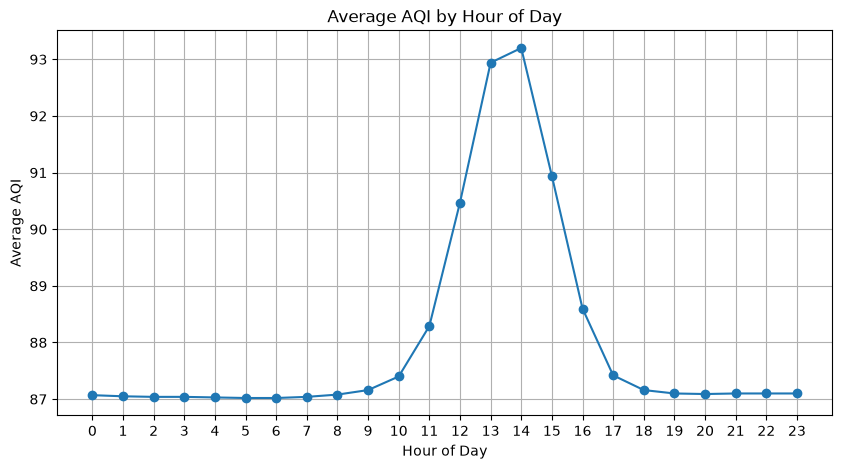

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_aqi.index,
    hourly_aqi["mean"],
    marker="o"
)

plt.title("Average AQI by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")
plt.xticks(range(24))
plt.grid(True)

plt.show()

## 7. Relationship Between Environmental Variables and AQI

### Question

Which environmental variables have the strongest relationship with AQI?

Understanding these relationships can help us identify potentially useful predictors and guide our feature-engineering decisions.

We will examine the correlation between AQI and the pollutant/weather variables.

In [34]:
correlation_with_aqi = (
    df.select_dtypes(include=np.number)
      .corr()["target_aqi"]
      .drop("target_aqi")
      .sort_values(ascending=False)
      .round(3)
)

correlation_with_aqi

pm25                0.722
sulphur_dioxide     0.504
carbon_monoxide     0.450
nitrogen_dioxide    0.358
pm10                0.242
ozone               0.149
aqi_change_rate     0.068
month               0.042
timestamp           0.038
hour                0.014
day_of_week        -0.008
day                -0.024
humidity           -0.340
temperature        -0.346
humidex            -0.473
Name: target_aqi, dtype: float64

## 6. Feature-to-Feature Correlation

Previously, we examined how individual features correlate with the target AQI.

Now we will examine correlations between the input features themselves.

The purpose is to identify highly correlated features that may contain overlapping information. This can help us understand multicollinearity and decide whether any feature-engineering or feature-selection decisions are necessary.

A high correlation between two input features does not automatically mean that one should be removed. We will use this analysis as evidence rather than making an automatic removal decision.

In [35]:
feature_corr = (
    df.select_dtypes(include=np.number)
      .drop(columns=["target_aqi"], errors="ignore")
      .corr()
)

feature_corr.round(3)

,timestamp,pm25,pm10,ozone,nitrogen_dioxide,sulphur_dioxide,carbon_monoxide,temperature,humidity,humidex,aqi_change_rate,hour,day,month,day_of_week
timestamp,1.000,0.034,0.000,0.028,-0.061,-0.001,-0.051,0.040,0.065,0.065,-0.001,0.001,0.037,-0.232,-0.001
pm25,0.034,1.000,0.513,-0.053,0.551,0.512,0.573,-0.340,-0.235,-0.408,0.099,0.017,-0.023,0.045,-0.013
pm10,0.000,0.513,1.000,0.067,-0.036,0.033,-0.039,0.252,-0.003,0.224,0.110,-0.085,-0.047,-0.058,0.001
ozone,0.028,-0.053,0.067,1.000,-0.518,0.351,-0.161,0.362,-0.625,0.006,0.160,-0.232,0.030,-0.106,0.003
nitrogen_dioxide,-0.061,0.551,-0.036,-0.518,1.000,0.406,0.731,-0.511,-0.008,-0.465,-0.081,0.215,-0.025,0.045,-0.003
sulphur_dioxide,-0.001,0.512,0.033,0.351,0.406,1.000,0.553,-0.233,-0.490,-0.451,0.086,-0.112,0.007,0.024,0.005
carbon_monoxide,-0.051,0.573,-0.039,-0.161,0.731,0.553,1.000,-0.490,-0.269,-0.565,-0.028,-0.054,-0.010,0.048,-0.016
temperature,0.040,-0.340,0.252,0.362,-0.511,-0.233,-0.490,1.000,0.027,0.876,0.071,-0.095,0.018,0.148,-0.003
humidity,0.065,-0.235,-0.003,-0.625,-0.008,-0.490,-0.269,0.027,1.000,0.491,-0.092,0.152,-0.013,-0.002,-0.014
humidex,0.065,-0.408,0.224,0.006,-0.465,-0.451,-0.565,0.876,0.491,1.000,0.014,-0.015,0.011,0.133,-0.007


## 7. Time-Series Continuity Check

Because this is an hourly forecasting problem, we need to verify that observations are recorded at regular one-hour intervals.

This is important because our forecasting features use 24-hour, 48-hour, and 72-hour shifts. If timestamps are missing, a 24-row shift may not represent exactly 24 hours.

We will check the time differences between consecutive observations and identify any missing or irregular time intervals.

In [37]:
time_diff = df["datetime"].sort_values().diff()

print("Time interval distribution:")
print(time_diff.value_counts().head(10))

print("\nNumber of intervals that are NOT exactly 1 hour:")
print((time_diff != pd.Timedelta(hours=1)).sum())

Time interval distribution:
datetime
0 days 01:00:00    17543
Name: count, dtype: int64

Number of intervals that are NOT exactly 1 hour:
1


## 8. Weekday vs Weekend AQI Patterns

We will compare AQI behavior between weekdays and weekends.

The purpose is to determine whether there is a meaningful difference in AQI levels or variability based on the day of the week.

This can help us decide whether calendar-based features such as `day_of_week` may provide useful information for forecasting.

In [38]:
df["is_weekend"] = df["day_of_week"].isin([5, 6])

weekend_analysis = (
    df.groupby("is_weekend")["target_aqi"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

weekend_analysis.index = ["Weekday", "Weekend"]

weekend_analysis

,count,mean,median,std,min,max
Weekday,12528,87.93,82.56,21.60,50.09,161.03
Weekend,5016,88.24,82.28,22.82,41.34,173.15


## 9. Multicollinearity Analysis

Correlation with the target tells us which individual features are associated with AQI.

However, features can also be strongly correlated with each other. This is called multicollinearity.

Strongly correlated features may contain overlapping information. This is particularly important for linear models such as Ridge Regression, while tree-based models such as XGBoost, Random Forest, and CatBoost generally handle correlated features differently.

We will identify strongly correlated feature pairs to understand whether any features may be providing redundant information.

In [39]:
# Select numerical features
feature_cols = [
    "pm25",
    "pm10",
    "ozone",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "carbon_monoxide",
    "temperature",
    "humidity",
    "humidex",
    "aqi_change_rate",
    "hour",
    "day",
    "month",
    "day_of_week"
]

# Calculate feature-to-feature correlations
feature_corr = df[feature_cols].corr()

# Keep only the upper triangle to avoid duplicate pairs
upper_triangle = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

# Convert correlations into a list of feature pairs
strong_correlations = (
    upper_triangle
    .stack()
    .reset_index()
)

strong_correlations.columns = ["Feature 1", "Feature 2", "Correlation"]

# Show only strong correlations
strong_correlations = (
    strong_correlations[
        strong_correlations["Correlation"].abs() >= 0.60
    ]
    .sort_values("Correlation", key=abs, ascending=False)
    .round(3)
)

strong_correlations

,Feature 1,Feature 2,Correlation
64,temperature,humidex,0.876
37,nitrogen_dioxide,carbon_monoxide,0.731
29,ozone,humidity,-0.625


## 10. Feature Relationships With Future AQI

Since this is a forecasting problem, correlation with the current AQI is not enough.

We will examine how the available environmental and temporal features relate to AQI 24, 48, and 72 hours into the future.

This helps us identify which features may contain useful predictive information for each forecasting horizon and can guide our feature-engineering decisions.

In [40]:
# Create future AQI targets
df["aqi_plus_24h"] = df["target_aqi"].shift(-24)
df["aqi_plus_48h"] = df["target_aqi"].shift(-48)
df["aqi_plus_72h"] = df["target_aqi"].shift(-72)

# Features we want to investigate
feature_cols = [
    "pm25",
    "pm10",
    "ozone",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "carbon_monoxide",
    "temperature",
    "humidity",
    "humidex",
    "aqi_change_rate",
    "hour",
    "day",
    "month",
    "day_of_week"
]

# Calculate correlations with each future horizon
future_correlations = pd.DataFrame({
    "Day +1 (24h)": df[feature_cols].corrwith(df["aqi_plus_24h"]),
    "Day +2 (48h)": df[feature_cols].corrwith(df["aqi_plus_48h"]),
    "Day +3 (72h)": df[feature_cols].corrwith(df["aqi_plus_72h"])
}).round(3)

future_correlations

,Day +1 (24h),Day +2 (48h),Day +3 (72h)
pm25,0.734,0.499,0.389
pm10,0.288,0.098,-0.028
ozone,0.144,0.132,0.114
nitrogen_dioxide,0.345,0.267,0.257
sulphur_dioxide,0.486,0.380,0.365
carbon_monoxide,0.452,0.374,0.360
temperature,-0.336,-0.331,-0.340
humidity,-0.347,-0.315,-0.301
humidex,-0.465,-0.445,-0.443
aqi_change_rate,0.116,0.067,0.051


## 11. Lag Analysis

AQI is a time-series variable, so recent historical AQI values may contain useful information about future AQI.

We will examine the relationship between the current AQI and its historical lagged values.

The goal is to identify useful lag periods such as 1, 3, 6, 12, 24, 48, and 72 hours.

These findings will help us decide which lag-based features should be considered during feature engineering.

In [41]:
# AQI lag analysis

lag_hours = [1, 3, 6, 12, 24, 48, 72, 168]

lag_results = {}

for lag in lag_hours:
    lagged_aqi = df["target_aqi"].shift(lag)
    correlation = df["target_aqi"].corr(lagged_aqi)
    lag_results[f"{lag}h"] = correlation

lag_analysis = (
    pd.Series(lag_results, name="Correlation with Current AQI")
    .round(3)
)

lag_analysis

1h      0.991
3h      0.949
6h      0.906
12h     0.842
24h     0.733
48h     0.547
72h     0.440
168h    0.330
Name: Correlation with Current AQI, dtype: float64

## 11.1 Lag Analysis Findings

AQI shows strong temporal dependence:

- 1h: 0.991
- 6h: 0.906
- 12h: 0.842
- 24h: 0.733
- 48h: 0.547
- 72h: 0.440
- 168h: 0.330

### Conclusion

Historical AQI contains useful information for forecasting, with strong relationships remaining at 24h, 48h, and 72h.

**Decision:** Investigate selected AQI lag features during feature engineering rather than adding all lags automatically.

## 12. Rolling AQI Analysis

Lag features capture AQI at specific points in the past.

Rolling statistics can capture the recent trend and variability of AQI.

We will examine rolling mean and standard deviation over 6-hour, 12-hour, and 24-hour windows to determine whether recent AQI behavior may provide useful information for forecasting.

In [42]:
# Create rolling AQI statistics

rolling_analysis = pd.DataFrame(index=df.index)

rolling_analysis["aqi_rolling_mean_6h"] = (
    df["target_aqi"].rolling(6).mean()
)

rolling_analysis["aqi_rolling_mean_12h"] = (
    df["target_aqi"].rolling(12).mean()
)

rolling_analysis["aqi_rolling_mean_24h"] = (
    df["target_aqi"].rolling(24).mean()
)

rolling_analysis["aqi_rolling_std_6h"] = (
    df["target_aqi"].rolling(6).std()
)

rolling_analysis["aqi_rolling_std_12h"] = (
    df["target_aqi"].rolling(12).std()
)

rolling_analysis["aqi_rolling_std_24h"] = (
    df["target_aqi"].rolling(24).std()
)

# Correlation of rolling statistics with future AQI
rolling_future_correlations = pd.DataFrame({
    "Day +1 (24h)": rolling_analysis.corrwith(df["aqi_plus_24h"]),
    "Day +2 (48h)": rolling_analysis.corrwith(df["aqi_plus_48h"]),
    "Day +3 (72h)": rolling_analysis.corrwith(df["aqi_plus_72h"])
}).round(3)

rolling_future_correlations

,Day +1 (24h),Day +2 (48h),Day +3 (72h)
aqi_rolling_mean_6h,0.698,0.526,0.423
aqi_rolling_mean_12h,0.671,0.510,0.414
aqi_rolling_mean_24h,0.639,0.494,0.410
aqi_rolling_std_6h,0.191,0.164,0.137
aqi_rolling_std_12h,0.198,0.165,0.137
aqi_rolling_std_24h,0.266,0.213,0.192


## 12.1 Rolling Analysis Findings

Rolling AQI means show meaningful relationships with future AQI, especially for Day +1.

The 6h, 12h, and 24h rolling means remain useful across all three forecasting horizons, while rolling standard deviation has weaker relationships.

**Decision:** Investigate selected rolling mean and volatility features during feature engineering, with emphasis on recent AQI levels and 24h variability.

# 13. Final EDA Findings & Feature Engineering Plan

Our EDA shows that AQI has strong temporal and seasonal patterns.

### Key Findings

- Data contains **17,544 hourly observations** with no missing values.
- AQI is **positively skewed** (skewness = 1.174).
- AQI varies substantially by **month**, with higher levels during winter months.
- PM2.5 is the strongest current predictor of AQI.
- AQI has strong **temporal dependence**, especially at 24h, 48h, and 72h lags.
- Rolling AQI means show meaningful relationships with future AQI.
- Some features are highly correlated with each other, such as temperature and humidex.

### Feature Engineering Direction

Based on these findings, we will investigate:

1. Selected AQI lag features (6h, 12h, 24h, 48h, 72h).
2. Selected rolling AQI statistics.
3. Lagged pollutant features, especially PM2.5, SO₂, and CO.
4. Cyclical time features for hour and month.
5. Trend/change features to capture recent AQI movement.

These features will be evaluated using time-based validation to determine whether they actually improve Day +1, Day +2, and Day +3 forecasting performance.